# WFJSSP-GA Demo Workflow

Dieses Notebook ist auf einen demo-orientierten Ablauf ausgelegt:
- Batch-Auswertung ueber mehrere oder alle FJSSP-W-Instanzen
- mehrere unabhaengige Runs pro Instanz
- getrennte finale Bewertung fuer Szenario 1 oder 2
- Export tabellarischer Resultate

Fuer Szenario 2 werden die Unsicherheitsparameter in dieser Demo standardmaessig mit `create_uncertainty_vector(...)` erzeugt.

Die stochastic evaluation verwendet vor `run_n_simulations(...)` jetzt eine Vorpruefung des decodierten Schedules. Nicht simulierbare Kandidaten werden verworfen und mit `makespan = inf` behandelt, statt mit einem `RecursionError` den Lauf abzubrechen.

In [1]:
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solver.GA.wfjssp_ga import build_ga_from_worker_encoding, is_simulatable_schedule
from util.benchmark_parser import WorkerBenchmarkParser
from util.evaluation import makespan, translate
from util.graph import run_n_simulations
from util.uncertainty import create_uncertainty_vector

plt.style.use("ggplot")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)


In [2]:
INSTANCES_DIR = Path("instances/fjssp-w")
RESULTS_DIR = Path("results/wfjssp_ga_competition")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO = 2  # 1 = deterministisch, 2 = Unsicherheit
STRICT_COMPETITION_MODE = False

# Optional: Datei mit offiziellen Unsicherheitsparametern.
# Erwartetes Format: {"instance_name.fjs": [[alpha, beta, offset], ...], ...}
OFFICIAL_UNCERTAINTY_FILE = None

# Standardverhalten der Demo: Parameter werden lokal erzeugt.
ALLOW_DEMO_UNCERTAINTY_FALLBACK = True
DEMO_UNCERTAINTY_SEED = 123
DEMO_UNCERTAINTY_FACTOR = 10.0
DEMO_UNCERTAINTY_OFFSET = 1.0
UNCERTAINTY_SOURCE = "worker"

# Competition-relevante Wiederholungen
N_INDEPENDENT_RUNS = 3
FINAL_EVAL_SIMULATIONS = 5

# Zum schnellen Testen kann die Auswahl reduziert werden.
#SELECTED_INSTANCES = sorted(p.name for p in INSTANCES_DIR.glob("*.fjs"))
SELECTED_INSTANCES = ["1_Brandimarte_7_workers.fjs"]

RUN_SEEDS = [1000 + i for i in range(N_INDEPENDENT_RUNS)]

# RL steuert die Gewichtung der drei Mutationsoperatoren:
# [Sequenzmutation, Maschinenmutation, Workermutation]
ENABLE_RL_MUTATION_CONTROL = True

GA_CONFIG = {
    "population_size": 100,
    "offspring_amount": 400,
    "elitism_rate": 0.1,
    "restart_generations": 100,
    "enable_rl_mutation_control": ENABLE_RL_MUTATION_CONTROL,
    "rl_update_interval": 16,
    "rl_warmup_generations": 0,
    "rl_history_length": 3,
    "rl_learning_rate": 1e-3,
    "rl_hidden_size": 32,
    "rl_gamma": 0.99,
    "rl_lambda": 0.95,
    "rl_clip_epsilon": 0.2,
    "rl_entropy_coef": 0.01,
    "rl_value_coef": 0.5,
}

RUN_CONFIG = {
    "max_generations": 250,
    "time_limit_s": 20,
    "keep_multiple": False,
    "do_restart": True,
}

pd.Series(
    {
        "scenario": SCENARIO,
        "strict_competition_mode": STRICT_COMPETITION_MODE,
        "instances": len(SELECTED_INSTANCES),
        "independent_runs": N_INDEPENDENT_RUNS,
        "final_eval_simulations": FINAL_EVAL_SIMULATIONS if SCENARIO == 2 else 0,
        "rl_mutation_control": ENABLE_RL_MUTATION_CONTROL,
        "results_dir": str(RESULTS_DIR),
    }
)

scenario                                               2
strict_competition_mode                            False
instances                                              1
independent_runs                                       3
final_eval_simulations                                 5
rl_mutation_control                                 True
results_dir                results/wfjssp_ga_competition
dtype: object

In [3]:
def load_official_uncertainty_map(path):
    if path is None:
        return None
    path = Path(path)
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


def get_uncertainty_parameters(instance_name, encoding, uncertainty_map):
    if SCENARIO != 2:
        return None, "disabled"

    if uncertainty_map is not None:
        if instance_name not in uncertainty_map:
            raise KeyError(f"No uncertainty parameters found for {instance_name}")
        return uncertainty_map[instance_name], "official"

    if STRICT_COMPETITION_MODE:
        raise ValueError(
            "Scenario 2 in strict competition mode requires OFFICIAL_UNCERTAINTY_FILE with provided parameters."
        )

    if not ALLOW_DEMO_UNCERTAINTY_FALLBACK:
        return None, "missing"

    random.seed(DEMO_UNCERTAINTY_SEED)
    resource_count = encoding.durations().shape[2] if UNCERTAINTY_SOURCE == "worker" else encoding.durations().shape[1]
    params = create_uncertainty_vector(
        resource_count,
        factor=DEMO_UNCERTAINTY_FACTOR,
        offset=DEMO_UNCERTAINTY_OFFSET,
    )
    return params, "demo_fallback"


def safe_workload_balance(machine_assignments, worker_assignments, durations):
    if not worker_assignments:
        return 0.0

    n_workers = max(worker_assignments) + 1
    working_time = [0] * n_workers
    for i in range(len(worker_assignments)):
        worker = int(worker_assignments[i])
        machine = int(machine_assignments[i])
        working_time[worker] += durations[i][machine][worker]

    mean_working_time = np.mean(working_time)
    result = 0.0
    for worker_time in working_time:
        result += (mean_working_time - worker_time) ** 2
    return float(result)


def solve_instance_with_ga(encoding, seed, uncertainty_parameters=None):
    ga_kwargs = dict(GA_CONFIG)
    ga_kwargs["seed"] = seed
    ga_kwargs["rl_seed"] = seed

    if SCENARIO == 2:
        ga_kwargs.update(
            {
                "use_stochastic_evaluation": True,
                "uncertainty_parameters": uncertainty_parameters,
                "n_simulations": FINAL_EVAL_SIMULATIONS,
            }
        )

    ga = build_ga_from_worker_encoding(encoding, **ga_kwargs)
    result = ga.run(**RUN_CONFIG)
    best = result["best"]

    start_times, machines, workers = translate(
        best.sequence,
        best.assignments,
        best.workers,
        encoding.durations(),
    )
    deterministic_makespan = float(makespan(start_times, machines, workers, encoding.durations()))
    worker_balance = safe_workload_balance(machines, workers, encoding.durations())

    raw_function_evaluations = int(result["function_evaluations"])
    competition_function_evaluations = raw_function_evaluations * FINAL_EVAL_SIMULATIONS if SCENARIO == 2 else raw_function_evaluations

    row = {
        "seed": seed,
        "runtime_s": float(result["runtime_s"]),
        "generations": int(result["generations"]),
        "raw_function_evaluations": raw_function_evaluations,
        "function_evaluations": competition_function_evaluations,
        "restarts": int(result["restarts"]),
        "deterministic_makespan": deterministic_makespan,
        "workload_balance": worker_balance,
        "sequence": list(best.sequence),
        "machines": list(best.assignments),
        "workers": list(best.workers),
        "start_times": list(start_times),
        "rl_enabled": bool(ga_kwargs.get("enable_rl_mutation_control", False)),
        "history": [dict(point) for point in result.get("history", [])],
    }

    if SCENARIO == 2:
        row["internal_robust_makespan"] = float(best.fitness.get("makespan"))
        row["internal_robust_stdev"] = float(best.fitness.get("robust_makespan_stdev"))
        row["internal_R"] = float(best.fitness.get("R"))
    else:
        row["internal_robust_makespan"] = None
        row["internal_robust_stdev"] = None
        row["internal_R"] = None

    return row


def evaluate_final_solution(row, encoding, uncertainty_parameters=None):
    if SCENARIO == 1:
        row["final_objective"] = row["deterministic_makespan"]
        row["final_robust_makespan"] = None
        row["final_robust_stdev"] = None
        row["final_R"] = None
        row["final_eval_simulations"] = 0
        row["final_eval_status"] = "deterministic"
        return row

    end_times = [
        row["start_times"][i] + encoding.durations()[i][int(row["machines"][i])][int(row["workers"][i])]
        for i in range(len(row["start_times"]))
    ]
    if not is_simulatable_schedule(
        row["start_times"],
        end_times,
        row["machines"],
        row["workers"],
        encoding.job_sequence(),
    ):
        row["final_objective"] = float("inf")
        row["final_robust_makespan"] = float("inf")
        row["final_robust_stdev"] = None
        row["final_R"] = None
        row["final_eval_simulations"] = 0
        row["final_simulation_results"] = []
        row["final_eval_status"] = "rejected_unsimulatable"
        return row

    try:
        results, robust_makespan, robust_makespan_stdev, R = run_n_simulations(
            row["start_times"],
            end_times,
            row["machines"],
            row["workers"],
            encoding.job_sequence(),
            encoding.durations(),
            uncertainty_parameters,
            FINAL_EVAL_SIMULATIONS,
            uncertainty_source=UNCERTAINTY_SOURCE,
            processing_times=True,
        )
    except (RecursionError, Exception):
        row["final_objective"] = float("inf")
        row["final_robust_makespan"] = float("inf")
        row["final_robust_stdev"] = None
        row["final_R"] = None
        row["final_eval_simulations"] = 0
        row["final_simulation_results"] = []
        row["final_eval_status"] = "simulation_error"
        return row
    row["final_objective"] = float(robust_makespan)
    row["final_robust_makespan"] = float(robust_makespan)
    row["final_robust_stdev"] = float(robust_makespan_stdev)
    row["final_R"] = float(R)
    row["final_eval_simulations"] = FINAL_EVAL_SIMULATIONS
    row["final_simulation_results"] = [float(x) for x in results]
    row["final_eval_status"] = "ok"
    return row


def drop_large_columns(df):
    cols = [
        "sequence",
        "machines",
        "workers",
        "start_times",
        "history",
        "final_simulation_results",
    ]
    keep = [c for c in df.columns if c not in cols]
    return df[keep].copy()

In [4]:
uncertainty_map = load_official_uncertainty_map(OFFICIAL_UNCERTAINTY_FILE)
parser = WorkerBenchmarkParser()

all_rows = []
instance_summaries = []

for instance_name in SELECTED_INSTANCES:
    instance_path = INSTANCES_DIR / instance_name
    encoding = parser.parse_benchmark(str(instance_path))
    uncertainty_parameters, uncertainty_mode = get_uncertainty_parameters(instance_name, encoding, uncertainty_map)

    print(f"Running {instance_name} | scenario={SCENARIO} | uncertainty_mode={uncertainty_mode}")

    instance_rows = []
    for run_idx, seed in enumerate(RUN_SEEDS, start=1):
        print(f"  run {run_idx}/{len(RUN_SEEDS)} seed={seed}")
        row = solve_instance_with_ga(encoding, seed, uncertainty_parameters)
        row["instance"] = instance_name
        row["run"] = run_idx
        row["scenario"] = SCENARIO
        row["uncertainty_mode"] = uncertainty_mode
        row = evaluate_final_solution(row, encoding, uncertainty_parameters)
        instance_rows.append(row)
        all_rows.append(row)

    instance_df = pd.DataFrame(instance_rows)
    metric_col = "final_objective"
    best_idx = instance_df[metric_col].idxmin()
    best_row = instance_df.loc[best_idx]
    instance_summaries.append(
        {
            "instance": instance_name,
            "best_run": int(best_row["run"]),
            "best_seed": int(best_row["seed"]),
            "best_final_objective": float(best_row["final_objective"]),
            "best_deterministic_makespan": float(best_row["deterministic_makespan"]),
            "best_function_evaluations": int(best_row["function_evaluations"]),
            "mean_final_objective": float(instance_df[metric_col].mean()),
            "std_final_objective": float(instance_df[metric_col].std(ddof=0)),
        }
    )

results_df = pd.DataFrame(all_rows)
summary_df = pd.DataFrame(instance_summaries)

status_counts = results_df["final_eval_status"].value_counts(dropna=False).to_dict() if not results_df.empty else {}
print(f"Completed {len(results_df)} runs across {len(summary_df)} instances without stochastic-evaluation aborts.")
print("Final evaluation status counts:", status_counts)

Running 1_Brandimarte_7_workers.fjs | scenario=2 | uncertainty_mode=demo_fallback
  run 1/3 seed=1000
  run 2/3 seed=1001
  run 3/3 seed=1002
Completed 3 runs across 1 instances without stochastic-evaluation aborts.
Final evaluation status counts: {'ok': 3}


In [5]:
metric_col = "final_objective"
secondary_col = "final_R" if SCENARIO == 2 else "workload_balance"

ranking_df = results_df.copy()
ranking_df["secondary_sort"] = ranking_df[secondary_col].fillna(np.inf)
ranking_df = ranking_df.sort_values(["instance", metric_col, "secondary_sort", "function_evaluations"])
ranking_df["rank_within_instance"] = ranking_df.groupby("instance").cumcount() + 1

instance_rank_scores = ranking_df.groupby("instance", as_index=False)["rank_within_instance"].sum()
overall_rank_score = int(instance_rank_scores["rank_within_instance"].sum())

pd.Series(
    {
        "runs_total": len(results_df),
        "instances_total": results_df["instance"].nunique(),
        "overall_rank_score_demo": overall_rank_score,
        "ranking_metric": metric_col,
        "ranking_secondary": secondary_col,
    }
)

runs_total                               3
instances_total                          1
overall_rank_score_demo                  6
ranking_metric             final_objective
ranking_secondary                  final_R
dtype: object

In [6]:
compact_results_df = drop_large_columns(results_df)
compact_results_df = compact_results_df.sort_values(["instance", "run"]).reset_index(drop=True)
summary_df = summary_df.sort_values("instance").reset_index(drop=True)

compact_results_path = RESULTS_DIR / "run_results.csv"
summary_path = RESULTS_DIR / "instance_summary.csv"
ranking_path = RESULTS_DIR / "ranking_results.csv"
solutions_json_path = RESULTS_DIR / "solutions.json"

compact_results_df.to_csv(compact_results_path, index=False)
summary_df.to_csv(summary_path, index=False)
ranking_df[[
    "instance",
    "run",
    "seed",
    "final_objective",
    "final_R",
    "workload_balance",
    "function_evaluations",
    "rank_within_instance",
]].to_csv(ranking_path, index=False)

solutions_payload = []
for row in results_df.to_dict(orient="records"):
    solutions_payload.append(
        {
            "instance": row["instance"],
            "run": int(row["run"]),
            "seed": int(row["seed"]),
            "final_objective": float(row["final_objective"]),
            "deterministic_makespan": float(row["deterministic_makespan"]),
            "function_evaluations": int(row["function_evaluations"]),
            "sequence": [int(x) for x in row["sequence"]],
            "machines": [int(x) for x in row["machines"]],
            "workers": [int(x) for x in row["workers"]],
            "start_times": [int(x) for x in row["start_times"]],
        }
    )

with solutions_json_path.open("w", encoding="utf-8") as fh:
    json.dump(solutions_payload, fh)

pd.Series(
    {
        "run_results": str(compact_results_path),
        "instance_summary": str(summary_path),
        "ranking_results": str(ranking_path),
        "solutions_json": str(solutions_json_path),
    }
)

run_results             results/wfjssp_ga_competition/run_results.csv
instance_summary    results/wfjssp_ga_competition/instance_summary...
ranking_results     results/wfjssp_ga_competition/ranking_results.csv
solutions_json           results/wfjssp_ga_competition/solutions.json
dtype: str

In [7]:
summary_df.head(20)

,instance,best_run,best_seed,best_final_objective,best_deterministic_makespan,best_function_evaluations,mean_final_objective,std_final_objective
0,1_Brandimarte_7_workers.fjs,1,1000,586.572074,278.0,32000,629.793527,30.618821


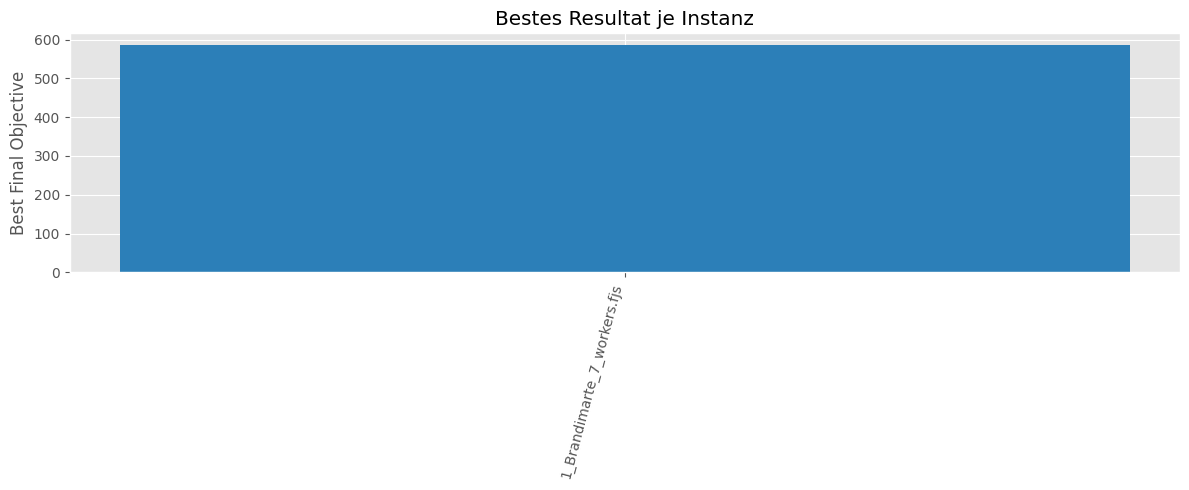

In [8]:
plt.figure(figsize=(12, 5))
plot_df = summary_df.copy()
plot_df = plot_df.sort_values("best_final_objective").head(min(15, len(plot_df)))
plt.bar(plot_df["instance"], plot_df["best_final_objective"], color="#2c7fb8")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Best Final Objective")
plt.title("Bestes Resultat je Instanz")
plt.tight_layout()
plt.show()

In [9]:
history_records = []
for row in results_df.to_dict(orient="records"):
    for point in row.get("history", []):
        history_records.append(
            {
                "instance": row["instance"],
                "run": int(row["run"]),
                "seed": int(row["seed"]),
                "generation": int(point["generation"]),
                "best_makespan": float(point["best_makespan"]),
                "overall_best_makespan": float(point["overall_best_makespan"]),
                "function_evaluations": int(point["function_evaluations"]),
                "mutation_probability": float(point["mutation_probability"]),
                "population_size": int(point["population_size"]),
                "offspring_amount": int(point["offspring_amount"]),
                "restarts": int(point["restarts"]),
                "runtime_s": float(point["runtime_s"]),
                "rl_enabled": bool(point.get("rl_enabled", False)),
                "mutation_mix": list(point.get("mutation_mix", [1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])),
                "rl_reward": float(point.get("rl_reward", 0.0)),
                "rl_value_estimate": point.get("rl_value_estimate"),
                "seq_mutations": int(point.get("seq_mutations", 0)),
                "machine_mutations": int(point.get("machine_mutations", 0)),
                "worker_mutations": int(point.get("worker_mutations", 0)),
            }
        )

history_df = pd.DataFrame(history_records)
if not history_df.empty:
    mix_df = pd.DataFrame(
        history_df["mutation_mix"].tolist(),
        columns=["mix_sequence", "mix_machine", "mix_worker"],
        index=history_df.index,
    )
    history_df = pd.concat([history_df.drop(columns=["mutation_mix"]), mix_df], axis=1)

pd.Series(
    {
        "history_points": len(history_df),
        "runs_with_history": history_df[["instance", "run"]].drop_duplicates().shape[0] if not history_df.empty else 0,
        "max_generation_seen": int(history_df["generation"].max()) if not history_df.empty else 0,
        "rl_enabled": bool(history_df["rl_enabled"].any()) if not history_df.empty else False,
    }
)

history_points           48
runs_with_history         3
max_generation_seen      16
rl_enabled             True
dtype: object

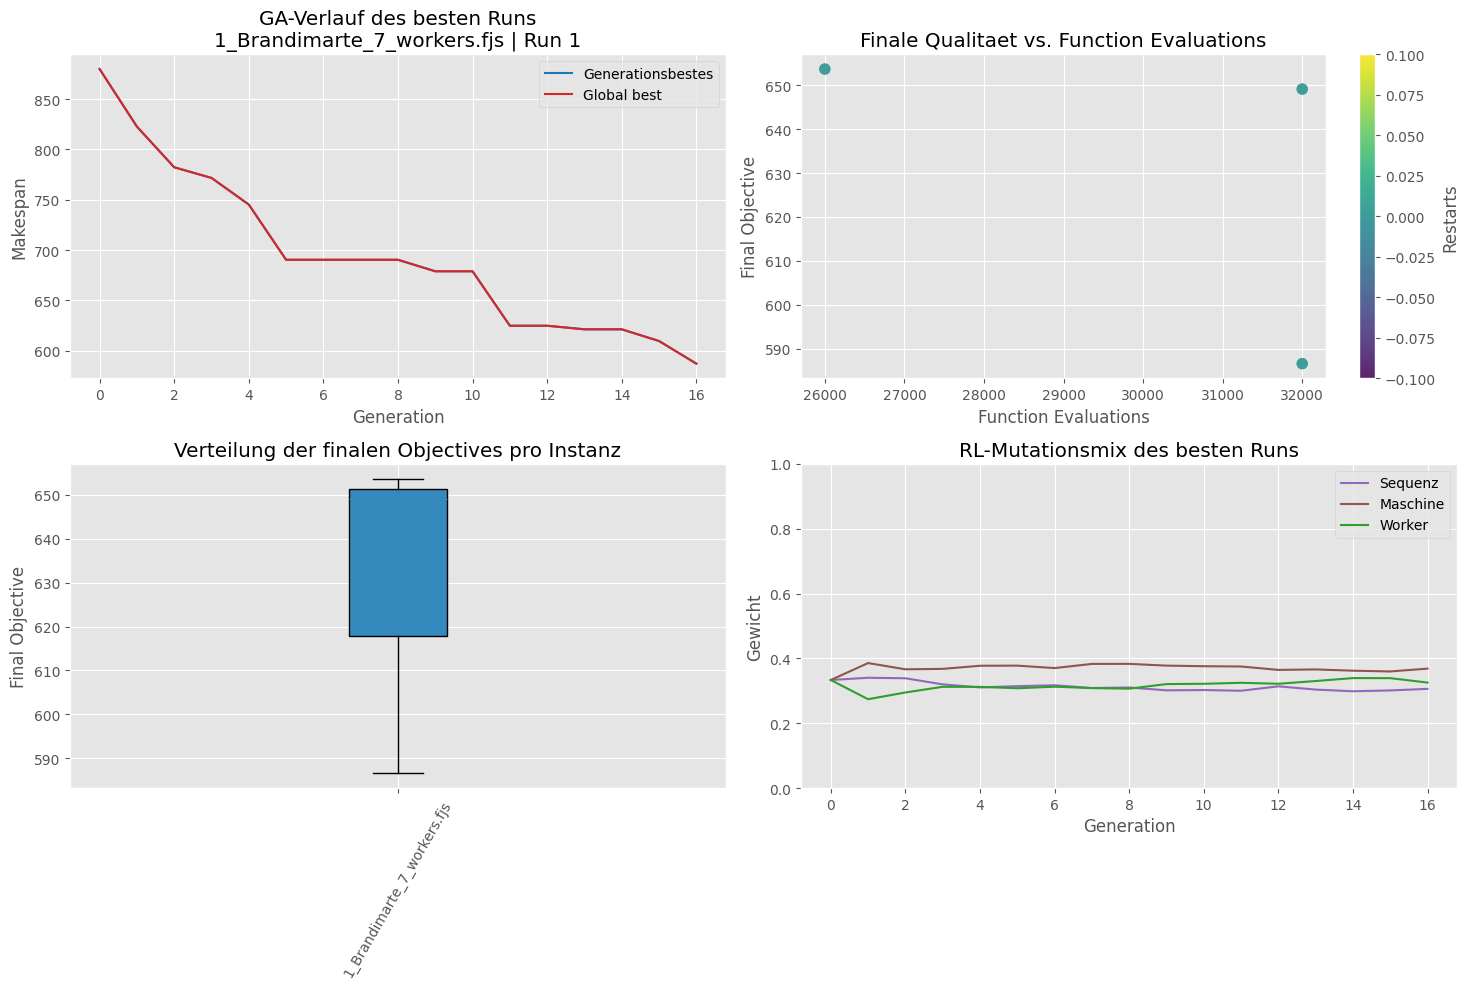

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if not history_df.empty:
    best_run = results_df.sort_values(["final_objective", "runtime_s"]).iloc[0]
    best_history = history_df[
        (history_df["instance"] == best_run["instance"])
        & (history_df["run"] == best_run["run"])
    ].sort_values("generation")
    axes[0, 0].plot(best_history["generation"], best_history["best_makespan"], label="Generationsbestes", color="#1f77b4")
    axes[0, 0].plot(best_history["generation"], best_history["overall_best_makespan"], label="Global best", color="#d62728")
    axes[0, 0].set_title(f"GA-Verlauf des besten Runs\n{best_run['instance']} | Run {int(best_run['run'])}")
    axes[0, 0].set_xlabel("Generation")
    axes[0, 0].set_ylabel("Makespan")
    axes[0, 0].legend()
else:
    axes[0, 0].set_visible(False)

scatter_df = results_df.copy()
scatter = axes[0, 1].scatter(
    scatter_df["function_evaluations"],
    scatter_df["final_objective"],
    c=scatter_df["restarts"],
    cmap="viridis",
    s=60,
    alpha=0.85,
)
axes[0, 1].set_title("Finale Qualitaet vs. Function Evaluations")
axes[0, 1].set_xlabel("Function Evaluations")
axes[0, 1].set_ylabel("Final Objective")
fig.colorbar(scatter, ax=axes[0, 1], label="Restarts")

box_df = results_df.copy()
top_instances = (
    box_df.groupby("instance", as_index=False)["final_objective"]
    .median()
    .sort_values("final_objective")
    .head(min(8, box_df["instance"].nunique()))["instance"]
    .tolist()
)
box_data = [box_df.loc[box_df["instance"] == instance, "final_objective"].dropna().tolist() for instance in top_instances]
axes[1, 0].boxplot(box_data, tick_labels=top_instances, patch_artist=True)
axes[1, 0].set_title("Verteilung der finalen Objectives pro Instanz")
axes[1, 0].set_ylabel("Final Objective")
axes[1, 0].tick_params(axis="x", rotation=60)

if not history_df.empty and "mix_sequence" in history_df.columns and history_df["rl_enabled"].any():
    axes[1, 1].plot(best_history["generation"], best_history["mix_sequence"], label="Sequenz", color="#9467bd")
    axes[1, 1].plot(best_history["generation"], best_history["mix_machine"], label="Maschine", color="#8c564b")
    axes[1, 1].plot(best_history["generation"], best_history["mix_worker"], label="Worker", color="#2ca02c")
    axes[1, 1].set_title("RL-Mutationsmix des besten Runs")
    axes[1, 1].set_xlabel("Generation")
    axes[1, 1].set_ylabel("Gewicht")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()
else:
    status_counts_plot = results_df["final_eval_status"].value_counts(dropna=False)
    axes[1, 1].bar(status_counts_plot.index.astype(str), status_counts_plot.values, color="#2ca02c")
    axes[1, 1].set_title("Status der finalen stochastic evaluation")
    axes[1, 1].set_ylabel("Runs")
    axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Hinweise

- Standardmaessig erzeugt das Notebook fuer Szenario 2 die Unsicherheitsparameter mit `create_uncertainty_vector(...)`.
- Wenn du spaeter offizielle Parameter verwenden willst, setze `OFFICIAL_UNCERTAINTY_FILE` und optional `STRICT_COMPETITION_MODE = True`.
- `run_results.csv` enthaelt die Kennzahlen pro Lauf.
- `final_eval_status` zeigt, ob die finale stochastic evaluation erfolgreich war oder ein Kandidat vorsichtshalber als nicht simulierbar verworfen wurde.
- `ENABLE_RL_MUTATION_CONTROL = True` aktiviert den RL-Agenten im GA. Der Agent waehlt pro Generation den Mutationsmix fuer Sequenz-, Maschinen- und Workermutationen.
- `history_df` enthaelt dazu `mix_sequence`, `mix_machine`, `mix_worker`, `rl_reward`, `rl_value_estimate` und die tatsaechlichen Mutationszaehler.
- `solutions.json` enthaelt die eigentlichen Planvektoren fuer eine spaetere Einreichung oder Nachpruefung.
- Die Ranking-Zelle bildet nur einen einfachen notebook-internen Score nach. Fuer eine echte Einreichung sollte das finale Competition-Scoring exakt an das verlangte Format angepasst werden.